# 17 - eta-plateau fluid (mode 3) vs exact: P(k) over k<=1, eta scan

Validation of `ncdm_ceff2_mode = 3`: the plateau closure driven directly by the injection kick, `cfs_acc = (1/3)(1 - exp(-3*A_eta*eta_acc))` with `A_eta = 0.55` fit to the exact-hierarchy ceff2 plateaus (eta = 0.01..0.5, kappa=6, a_t=0.13). Success = `max|P_fluid/P_exact - 1| <~ 1%` over **k <= 1 Mpc^-1** across the full eta scan.

- f = 0.1 to match the family where the plateaus were measured, and where the exact reference is converged at `q_size = 1001` (`memory: accdm-fluid-f-boundary`).
- k <= 1 ONLY (nb7 failed because it scored on k <= 10, where the fluid blows up architecturally).
- **nb16 caveat:** nb16's "mode 2" fluid runs actually set `ncdm_ceff2_mode = 1` (cell-5 typo), so its catastrophic residuals never tested a plateau closure. This notebook sets mode 3 explicitly and asserts the stored `cs2_ncdm[1]` matches the python mirror, so a silent mode fallback cannot go unnoticed.
- Only `ceff2` is fixed here. If P(k) misses 1% with the correct ceff2, the shear closure (`cvis2`, still default `3*w*ca2`) is the **named suspect** - do not tune ceff2 further.

Requires the rebuilt `classy` with mode 3. Runs are pickle-cached under `accDM_scans/nb17_cache/`.

In [1]:
import sys, os, time, pickle; sys.path.insert(0, '.')
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from classy import Class
from fluid_closure_helpers import eta_plateau_cfs

plt.rcParams.update({
    'mathtext.fontset': 'stix', 'font.family': 'serif', 'font.size': 11,
    'axes.labelsize': 12, 'legend.fontsize': 9, 'lines.linewidth': 1.5, 'figure.dpi': 200})
qual_colors = ['#377eb8', '#ff7f00', '#4daf4a', '#f781bf', '#984ea3']

# --- base cosmology + accDM model (same as nb15/nb16) ---
omega_b, omega_cdm0 = 0.022383, 0.12011
A_s, n_s, tau_reio, H0 = 2.1005829616811546e-9, 0.96605, 0.0543, 67.32
base_params = {'omega_b': omega_b, 'omega_cdm': omega_cdm0, 'H0': H0,
               'A_s': A_s, 'n_s': n_s, 'tau_reio': tau_reio}
PREC = {'output': 'mPk', 'P_k_max_1/Mpc': 1.0, 'z_max_pk': 0.0,
        'evolver': 0, 'reionization_z_start_max': 80}

A_T, MASS, KAPPA = 0.13, 1e16, 6.0
A_REC = 1.0 / (1.0 + 1090.0)

# --- test matrix: the eta scan the plateau fit was made on ---
K_PK     = np.logspace(-3, 0.0, 40)            # k <= 1 ONLY
F_TEST   = 0.1
ETA_TEST = [0.01, 0.05, 0.1, 0.3, 0.5]
Q_EXACT  = 1001                                 # converged at f<=0.1 (memory: accdm-fluid-f-boundary)
TRIGGERS = [0.4, 0.1]                           # safe switch-on + one aggressive probe
A_ETA    = 0.55                                 # ncdm_ceff2_eta_A (default; passed explicitly)
CACHE_DIR = os.path.join('accDM_scans', 'nb17_cache'); os.makedirs(CACHE_DIR, exist_ok=True)

def accdm_params(eta, f_acc=F_TEST, kappa=KAPPA, a_t=A_T, q_size=Q_EXACT):
    """Exact-hierarchy accDM params (nb15 baseline) with adjustable daughter q-grid."""
    ocdm = omega_cdm0 * (1 + f_acc*(1 - A_REC**kappa)/(1 + (A_REC/a_t)**kappa))**(-1)
    params = dict(base_params); params.update(PREC)
    params.update({'omega_cdm': ocdm,
                   'vary_Gamma_acc': 'yes', 'kappa_acc': kappa, 'a_t_acc': a_t,
                   'f_acc': f_acc, 'eta_acc': eta,
                   'm_acc_in_GeV': MASS, 'm_cdm_in_GeV': MASS,
                   'N_ncdm': 2, 'deg_ncdm': '3, 1',
                   'm_ncdm': '0.02, {:.6e}'.format(MASS*1e9),
                   'T_ncdm': '0.71611, 1', 'ncdm_quadrature_strategy': '0, 4',
                   'ncdm_N_momentum_bins': '15, {}'.format(q_size), 'N_ur': 0.00441,
                   'background_Nloga': 5001, 'gauge': 'synchronous',
                   'get_perturbations_in_current_gauge': 'yes',
                   'ncdm_fluid_trigger_tau_over_tau_k': 25,
                   'ncdm_fluid_approximation': 3})          # 3 = none (exact hierarchy)
    return params

def fluid_params(eta, trigger):
    p = accdm_params(eta)
    p['ncdm_fluid_approximation'] = 2
    p['ncdm_fluid_trigger_rho_accDM_over_rho_dcdm'] = trigger
    p['switch_off_shear_acc'] = 'no'
    p['ncdm_ceff2_mode'] = 3                     # eta-driven plateau (THIS is the mode under test)
    p['ncdm_ceff2_eta_A'] = A_ETA
    return p

def run_pk_timed(params, k_list, tag):
    """P(k) at z=0 with wall-time; pickle-cached by tag. Prints cache-hit vs
    computing so a fast return is never mistaken for a skipped run."""
    cache_path = os.path.join(CACHE_DIR, tag + '.pkl')
    if os.path.exists(cache_path):
        print('[cache hit] {}'.format(tag), flush=True)
        with open(cache_path, 'rb') as cache_file:
            return pickle.load(cache_file)
    print('[computing] {} ...'.format(tag), flush=True)
    M = Class(); M.set(params)
    start = time.perf_counter(); M.compute(); elapsed = time.perf_counter() - start
    pk = np.array([M.pk(float(k), 0.0) for k in k_list])
    M.struct_cleanup(); M.empty()
    print('[done]      {} in {:.0f} s'.format(tag, elapsed), flush=True)
    result = (pk, elapsed)
    with open(cache_path, 'wb') as cache_file:
        pickle.dump(result, cache_file)
    return result

print('setup OK; mode-3 plateau prediction vs exact-scan plateaus (eyeballed):')
for eta, measured in [(0.01, 5.5e-3), (0.05, 2.7e-2), (0.1, 5.3e-2), (0.3, 1.3e-1), (0.5, 1.8e-1)]:
    model = float(eta_plateau_cfs(eta, A=A_ETA))
    print('  eta={:<5}: model {:.4f}  measured {:.4f}  ({:+.1%})'.format(
        eta, model, measured, model/measured - 1))

setup OK; mode-3 plateau prediction vs exact-scan plateaus (eyeballed):
  eta=0.01 : model 0.0055  measured 0.0055  (-0.8%)
  eta=0.05 : model 0.0264  measured 0.0270  (-2.2%)
  eta=0.1  : model 0.0507  measured 0.0530  (-4.3%)
  eta=0.3  : model 0.1301  measured 0.1300  (+0.1%)
  eta=0.5  : model 0.1873  measured 0.1800  (+4.0%)


## Reference - converged exact at f=0.1 (cached)

`q_size = 1001` is converged at f <= 0.1 (`memory: accdm-fluid-f-boundary`). rkck evolver (`evolver: 0`) throughout (`memory: ndf15-oom-high-q`).

In [2]:
REF = {}
for eta in ETA_TEST:
    p = accdm_params(eta)                        # exact hierarchy
    REF[eta] = run_pk_timed(p, K_PK, 'ref_eta{:g}_f{:g}_q{}'.format(eta, F_TEST, Q_EXACT))
    print('exact ref eta={}: {:.0f} s'.format(eta, REF[eta][1]))

[computing] ref_eta0.01_f0.1_q1001 ...
[done]      ref_eta0.01_f0.1_q1001 in 44 s
exact ref eta=0.01: 44 s
[computing] ref_eta0.05_f0.1_q1001 ...
[done]      ref_eta0.05_f0.1_q1001 in 45 s
exact ref eta=0.05: 45 s
[computing] ref_eta0.1_f0.1_q1001 ...
[done]      ref_eta0.1_f0.1_q1001 in 38 s
exact ref eta=0.1: 38 s
[computing] ref_eta0.3_f0.1_q1001 ...
[done]      ref_eta0.3_f0.1_q1001 in 39 s
exact ref eta=0.3: 39 s
[computing] ref_eta0.5_f0.1_q1001 ...
[done]      ref_eta0.5_f0.1_q1001 in 41 s
exact ref eta=0.5: 41 s


## Mode-3 fluid runs

In [3]:
RES = {}                                          # RES[(eta, trig)] = (max, rms, dt)
PKF = {}
for eta in ETA_TEST:
    pk_ref, _ = REF[eta]
    for trig in tqdm(TRIGGERS, desc='eta={}'.format(eta)):
        try:
            pk, dt = run_pk_timed(fluid_params(eta, trig), K_PK,
                                  'fluid3_eta{:g}_trig{:g}'.format(eta, trig))
            PKF[(eta, trig)] = pk
            r = pk/pk_ref - 1.0
            RES[(eta, trig)] = (float(np.nanmax(np.abs(r))),
                                float(np.sqrt(np.nanmean(r**2))), dt)
        except Exception as e:
            RES[(eta, trig)] = None
            print('CRASH eta={} trig={}: {}'.format(eta, trig, str(e)[:120]))

print('{:>5} {:>6} | {:>9} {:>9} {:>8}'.format('eta', 'trig', 'max', 'rms', 'time[s]'))
for (eta, trig), v in RES.items():
    print('{:>5} {:>6} | {}'.format(eta, trig,
          '{:>9.2e} {:>9.2e} {:>8.0f}'.format(*v) if v else '    CRASH'))

eta=0.01:   0%|          | 0/2 [00:00<?, ?it/s]

[computing] fluid3_eta0.01_trig0.4 ...
[done]      fluid3_eta0.01_trig0.4 in 26 s


eta=0.01:  50%|█████     | 1/2 [00:26<00:26, 26.18s/it]

[computing] fluid3_eta0.01_trig0.1 ...
[done]      fluid3_eta0.01_trig0.1 in 25 s


eta=0.05:   0%|          | 0/2 [00:00<?, ?it/s]

...

[computing] fluid3_eta0.5_trig0.4 ...
[done]      fluid3_eta0.5_trig0.4 in 25 s


eta=0.5:  50%|█████     | 1/2 [00:28<00:28, 28.58s/it]

[computing] fluid3_eta0.5_trig0.1 ...
[done]      fluid3_eta0.5_trig0.1 in 24 s


eta=0.5: 100%|██████████| 2/2 [00:56<00:00, 28.25s/it]

  eta   trig |       max       rms  time[s]
 0.01    0.4 |  3.96e-01  8.99e-02       26
 0.01    0.1 |  5.57e-01  1.22e-01       25
 0.05    0.4 |  6.23e-01  1.55e-01       28
 0.05    0.1 |  1.61e+00  3.42e-01       27
  0.1    0.4 |  4.96e+02  8.50e+01       27
  0.1    0.1 |  1.69e+03  2.93e+02       24
  0.3    0.4 |  4.25e+03  6.72e+02       25
  0.3    0.1 |  8.05e+03  1.27e+03       25
  0.5    0.4 |  5.07e+00  8.62e-01       25
  0.5    0.1 |  2.99e+00  7.02e-01       24


## C-vs-python plateau consistency (guards against the nb16 mode typo)

After the fluid switches on, the stored `cs2_ncdm[1]` equals the mode-3 helper value; at late times (`ca2 << c_fs`) that is exactly `pba->cfs_acc = eta_plateau_cfs(eta)`. Tight 1% tolerance: unlike mode 2, both sides are closed-form functions of the same input `eta_acc`, so any disagreement means the C code is not running mode 3.

In [4]:
p = fluid_params(0.1, 0.4); p['k_output_values'] = '0.1'
M = Class(); M.set(p); M.compute()
d = M.get_perturbations()['scalar'][0]
cfs_C = float(np.asarray(d['cs2_ncdm[1]'], float)[-1])   # late-time = plateau
M.struct_cleanup(); M.empty()

cfs_py = float(eta_plateau_cfs(0.1, A=A_ETA))
print('C plateau {:.5f} vs python {:.5f} ({:+.2%})'.format(cfs_C, cfs_py, cfs_C/cfs_py - 1))
assert abs(cfs_C/cfs_py - 1) < 0.01, 'C is NOT running the mode-3 eta plateau'

C plateau 0.05070 vs python 0.05070 (+0.00%)


## Residuals over k<=1

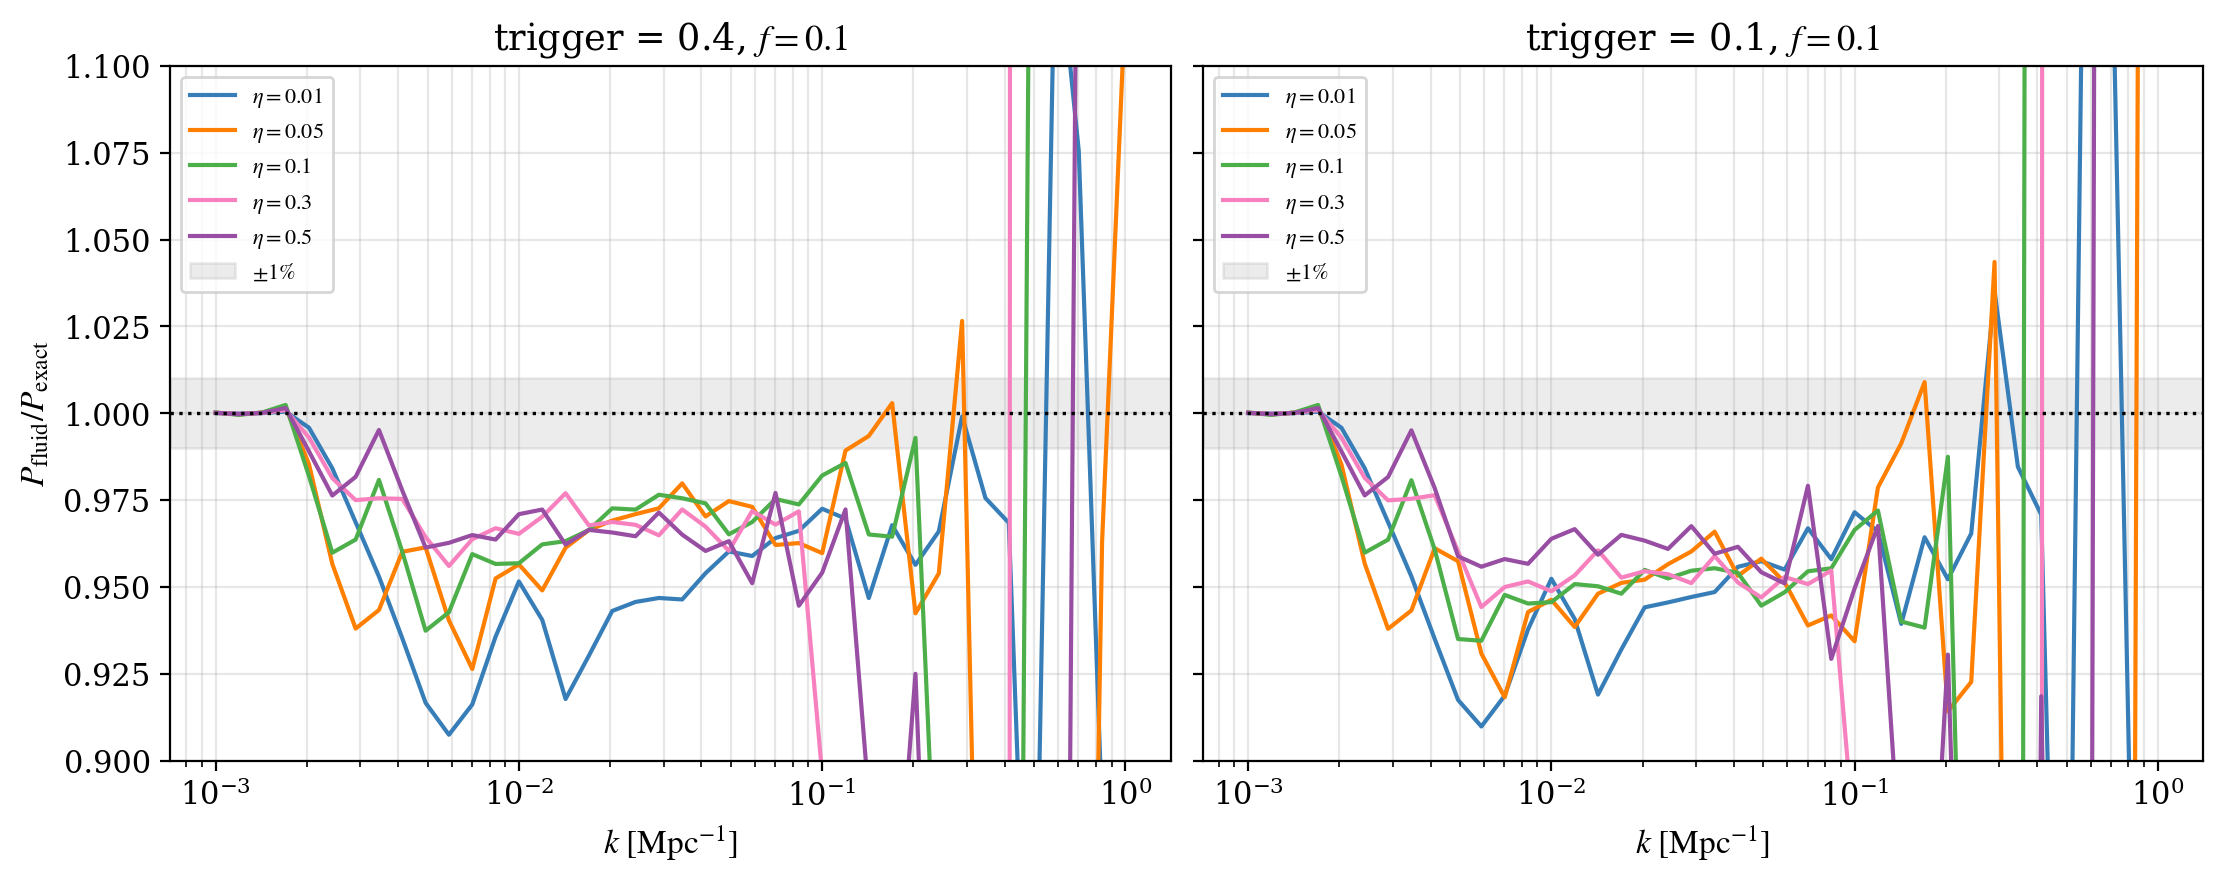

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3), constrained_layout=True, sharey=True)
for ax, trig in zip(axes, TRIGGERS):
    for eta, color in zip(ETA_TEST, qual_colors):
        if (eta, trig) in PKF:
            pk_ref, _ = REF[eta]
            ax.semilogx(K_PK, PKF[(eta, trig)]/pk_ref, '-', color=color,
                        label=r'$\eta={}$'.format(eta))
    ax.axhline(1.0, color='black', ls=':', lw=1.2)
    ax.axhspan(0.99, 1.01, color='gray', alpha=0.15, label=r'$\pm 1\%$')
    ax.set_xlabel(r'$k\ [\mathrm{Mpc}^{-1}]$')
    ax.set_title('trigger = {}, $f={}$'.format(trig, F_TEST))
    ax.grid(True, which='both', alpha=0.3); ax.legend(fontsize=8)
    ax.set_ylim(0.9, 1.1)
axes[0].set_ylabel(r'$P_{\rm fluid}/P_{\rm exact}$')
plt.show()

## Verdict (fill from output)

- max residual over k<=1 at f=0.1, trigger 0.4: [FILL per eta]; trigger 0.1: [FILL].
- meets ~1% across the eta scan? [YES/NO]. If NO with the correct ceff2 -> **cvis2 (shear closure) is the named suspect**; do not tune ceff2 further.
- wall-time: exact ref [FILL] s vs fluid [FILL] s -> speedup [FILL]x; compare against the safe q-size reduction (`memory: daughter-qsize-overkill`) before adopting.
- C-vs-python plateau: [FILL]% agreement (must be <1%; a miss means the mode is not wired in).
- If residuals grow systematically with eta -> the plateau amplitude law is fine but `A_eta` needs a refit; if they grow with k at fixed eta -> the k-independence assumption (or shear) is the problem.

**Keep in sync:** `eta_plateau_cfs` (python) mirrors the mode-3 branch of `pba->cfs_acc` (background.c); the closure branch lives in `perturbations_ceff2_ncdm`. `A_eta = 0.55` is measured at kappa=6, a_t=0.13 only - universality in (kappa, a_t) is untested.